In [1]:
# %matplotlib ipympl
import matplotlib.pyplot as plt
import numpy  as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

torch.set_default_dtype(torch.float32)

In [2]:
# select compute device
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Metal")
else:
    if not torch.backends.mps.is_built():
        print("MPS not available because the current PyTorch install was not "
              "built with MPS enabled.")
    else:
        print("MPS not available because the current MacOS version is not 12.3+ "
              "and/or you do not have an MPS-enabled device on this machine.")

    if torch.cuda.is_available():
        device = torch.device("cuda:0")
        print("Using CUDA")

    else:
        device = torch.device("cpu")
        print("Using CPU")

Using Metal


In [3]:
file = '../data/FeCr/new_truncated_generated_data.csv'

In [4]:
df = pd.read_csv(file)

In [5]:
# # Analysis of dataframe
# df.head()
# df.tail()
# df.shape
# df.info()
# df.keys()
# df.describe()
df.columns
# df.dtypes
# df.isnull() # Booleans indicating missing values
# df.isnull().sum # Number of missing values

Index(['X(CR)', 'TEMPERATURE', 'G(FCC_A1)', 'G(BCC_A2)', 'G(LIQUID)'], dtype='object')

In [6]:
inputs = ['X(CR)', 'TEMPERATURE']
outputs = ['G(FCC_A1)', 'G(BCC_A2)', 'G(LIQUID)']

In [7]:
input_df = df[inputs]

In [8]:
# output_df = df.drop(inputs, axis=1)
output_df = df[outputs]

In [9]:
# Use 66.6% for training and the rest for testing
train_len = int(len(df) * 0.666)

# Split into train and test sets
choice = np.random.choice(range(len(df)), size=(train_len,), replace=False)

train_idx = np.zeros(len(df), dtype=bool)
train_idx[choice] = True
test_idx = ~train_idx

X_all, Y_all = torch.tensor(np.asarray(input_df), dtype=torch.float32), torch.tensor(np.asarray(output_df), dtype=torch.float32)
X_train, Y_train = X_all[train_idx], Y_all[train_idx]
X_test, Y_test = X_all[test_idx], Y_all[test_idx]

In [10]:
# Data normalization
X_mean = X_all.mean(0, keepdim=True)
X_std = X_all.std(0, keepdim=True)
Y_mean = Y_all.mean(0, keepdim=True)
Y_std = Y_all.std(0, keepdim=True)
# Y_mean = Y_all.mean(0, keepdims=True)
# Y_std = Y_all.std(0, keepdims=True)

def scaled_data(Xu, Yu):
  global X_mean, X_std, Y_mean, Y_std
  X = Xu.detach().clone()
  Y = Yu.detach().clone()
  return((X - X_mean) / X_std, (Y - Y_mean) / Y_std)

# normalized data
X_all_scaled, Y_all_scaled = scaled_data(X_all, Y_all)
X_train_scaled, Y_train_scaled = scaled_data(X_train, Y_train)
X_test_scaled, Y_test_scaled = scaled_data(X_test, Y_test)

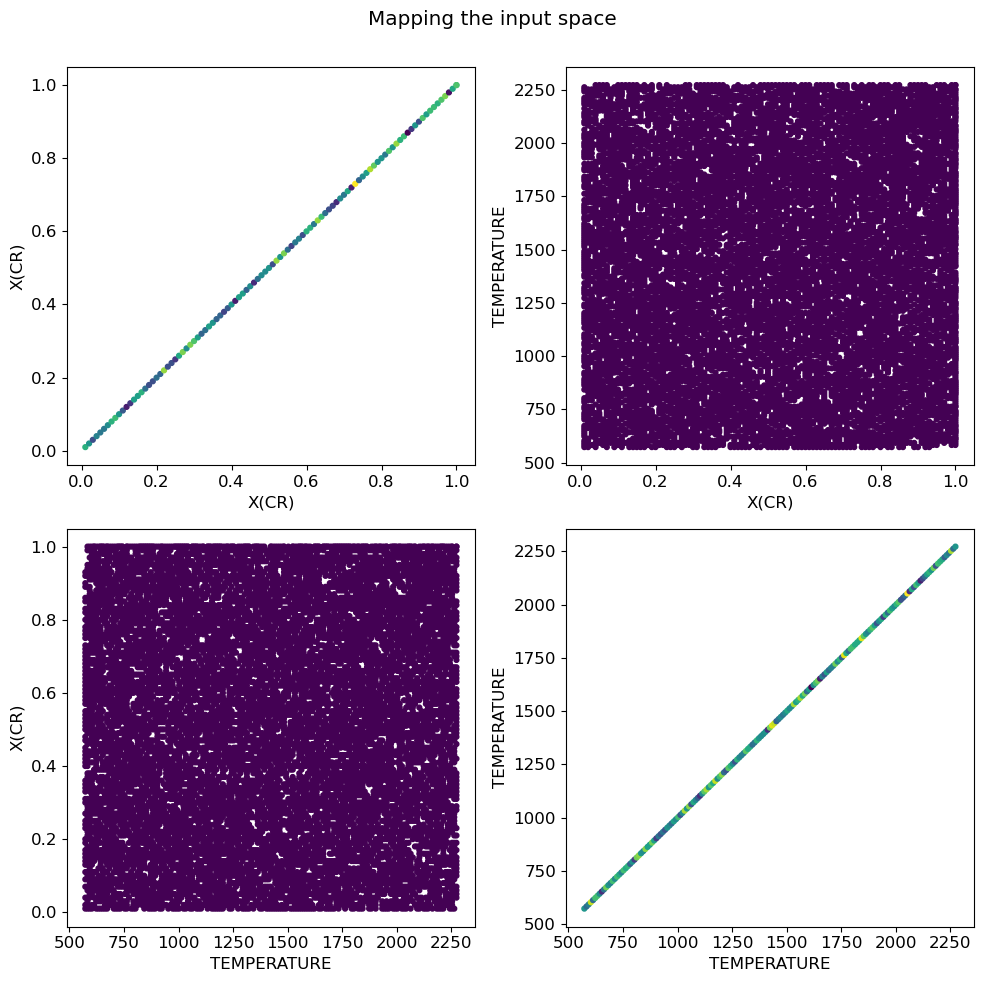

In [11]:
plt.close()
n_cols = len(inputs)
plt.rcParams.update({'font.size': 12})
fig, ax = plt.subplots(nrows=n_cols, ncols=n_cols, figsize = (10, 10))

for i in range(n_cols):
  for j in range(n_cols):
    # only plot unique points for speed
    reduced, counts = np.unique(np.transpose(np.array([X_train[:,i], X_train[:,j]])), axis=0, return_counts=True)
    rx, ry = np.transpose(reduced)

    ax[i][j].scatter(rx, ry, c=counts, s=12)
    ax[i][j].set_xlabel(inputs[i])
    ax[i][j].set_ylabel(inputs[j])
    # ax[i][j].set_xscale('log')
    # ax[i][j].set_yscale('log')

fig.suptitle("Mapping the input space\n")
# plt.savefig('figures/input_space2.pdf')
fig.tight_layout()

plt.show()
# plt.close()

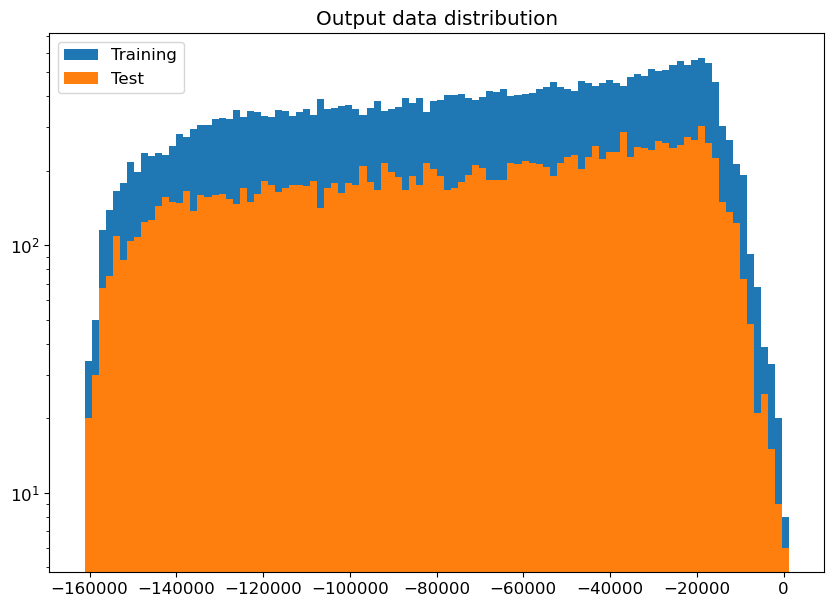

In [12]:
plt.close()
# Creating figure
fig = plt.figure(figsize = (10, 7))
ax = plt.axes()

ax.hist(Y_train[:].flatten().cpu(), bins=100, label="Training")
ax.hist(Y_test[:].flatten().cpu(), bins=100, label="Test")
ax.set_xlabel("")
ax.set_yscale('log')
plt.title("Output data distribution")
plt.legend()

# show plot
plt.show()

In [13]:
losses = []

In [14]:
input_size = X_test_scaled.shape[1]
hidden_size = [50, 100, 100, 50]
output_size = Y_test_scaled.shape[1]

model = nn.Sequential(
    nn.Linear(input_size, hidden_size[0]),
    nn.Sigmoid(),
    nn.Linear(hidden_size[0], hidden_size[1]),
    nn.ReLU(),
    nn.Linear(hidden_size[1], hidden_size[2]),
    nn.ReLU(),
    nn.Linear(hidden_size[2], hidden_size[3]),
    nn.ReLU(),
    nn.Linear(hidden_size[3], output_size))#,

In [15]:
loss_fn = nn.MSELoss()  # binary cross entropy
# loss_fn = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)#, weight_decay=1e-5)#, weight_decay=1e-4

In [16]:
X = X_train_scaled.to(device)
y = Y_train_scaled.float().to(device)
model.to(device)

Sequential(
  (0): Linear(in_features=2, out_features=50, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=50, out_features=100, bias=True)
  (3): ReLU()
  (4): Linear(in_features=100, out_features=100, bias=True)
  (5): ReLU()
  (6): Linear(in_features=100, out_features=50, bias=True)
  (7): ReLU()
  (8): Linear(in_features=50, out_features=3, bias=True)
)

In [17]:
n_epochs = 2500
batch_size = 100

for epoch in range(n_epochs):
    for i in range(0, len(X), batch_size):
        Xbatch = X[i:i+batch_size]
        y_pred = model(Xbatch)
        ybatch = y[i:i+batch_size]                        # Without softmax normalization
        # ybatch = y_train_normalized[i:i+batch_size]             # With softmax normalization
        loss = loss_fn(y_pred, ybatch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    losses.append(loss.item())
    print(f'Finished epoch {epoch}/{n_epochs} - Loss: {loss}')

Finished epoch 0/2500 - Loss: 1.0918803215026855
Finished epoch 1/2500 - Loss: 0.9749270677566528
Finished epoch 2/2500 - Loss: 0.699449896812439
Finished epoch 3/2500 - Loss: 0.25408926606178284
Finished epoch 4/2500 - Loss: 0.02349117398262024
Finished epoch 5/2500 - Loss: 0.006366430781781673
Finished epoch 6/2500 - Loss: 0.006410377565771341
Finished epoch 7/2500 - Loss: 0.006165387574583292
Finished epoch 8/2500 - Loss: 0.005590721499174833
Finished epoch 9/2500 - Loss: 0.00511320261284709
Finished epoch 10/2500 - Loss: 0.004811780992895365
Finished epoch 11/2500 - Loss: 0.004658875986933708
Finished epoch 12/2500 - Loss: 0.004640276078134775
Finished epoch 13/2500 - Loss: 0.004667110741138458
Finished epoch 14/2500 - Loss: 0.00468116020783782
Finished epoch 15/2500 - Loss: 0.004724083002656698
Finished epoch 16/2500 - Loss: 0.004750473890453577
Finished epoch 17/2500 - Loss: 0.004756222944706678
Finished epoch 18/2500 - Loss: 0.004747389815747738
Finished epoch 19/2500 - Loss: 0.

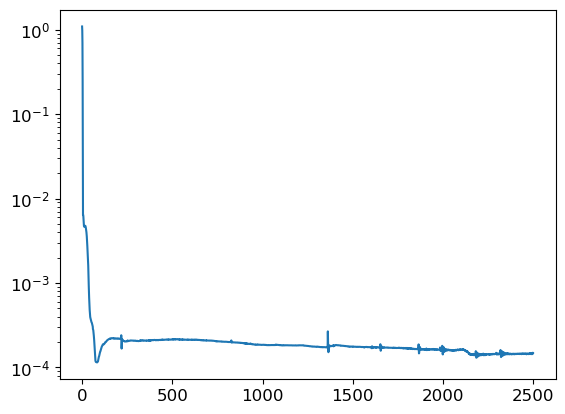

In [18]:
plt.close()
plt.plot()
plt.semilogy(losses)
plt.show()

In [19]:
# compute accuracy for test data set
with torch.no_grad():
    y_pred = model(X_test_scaled.to(device)).cpu() * Y_std + Y_mean

# diff = np.exp(y_pred) - np.exp(Y_test)
# accuracy =diff.mean()
# delta_min = diff.min()
# delta_max = diff.max()
# print(f"Absolute Accuracy {accuracy},  Min {delta_min}, Max {delta_max}")

# diff = (np.exp(y_pred) - np.exp(Y_test))  / np.exp(Y_test)
# accuracy =(diff**2).mean()**.5
# delta_min = (diff**2).min()**.5
# delta_max = (diff**2).max()**.5
# print(f"Relative Accuracy {accuracy},  Min {delta_min}, Max {delta_max}")

In [20]:
(Y_test - y_pred) / y_pred

tensor([[-0.0076, -0.0068, -0.0091],
        [-0.0036, -0.0031, -0.0033],
        [-0.0045, -0.0039, -0.0040],
        ...,
        [-0.0114, -0.0136, -0.0243],
        [-0.0129, -0.0122, -0.0285],
        [-0.0123, -0.0107, -0.0322]])

In [21]:
y_pred

tensor([[-58473.5391, -58391.9141, -54156.3594],
        [-59258.1172, -59173.0547, -55359.8320],
        [-59399.0508, -59312.1406, -55571.6250],
        ...,
        [-18830.1523, -24242.9414, -12912.9922],
        [-18035.5391, -24071.2852, -11381.2617],
        [-16082.1523, -23386.3828,  -7771.2891]])

/var/folders/wc/8ppk7xj10vbc_xtfrp0k7bnnjj2tt8/T/ipykernel_31507/4103050436.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.scatter(X_test[:,0], np.abs((y_pred[:,0]-Y_test[:,0])/Y_test[:,0]), marker='.', alpha=0.2, label='FCC')
/var/folders/wc/8ppk7xj10vbc_xtfrp0k7bnnjj2tt8/T/ipykernel_31507/4103050436.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.scatter(X_test[:,0], np.abs((y_pred[:,1]-Y_test[:,1])/Y_test[:,1]), marker='.', alpha=0.2, label='BCC')
/var/folders/wc/8ppk7xj10vbc_xtfrp0k7bnnjj2tt8/T/ipykernel_31507/4103050436.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.scatter(X_test[:,0], np.abs((y_pred[:,2]-Y_test[:,2])/Y_test[:,2]), marker='.', alpha=0.2, label='Liquid')


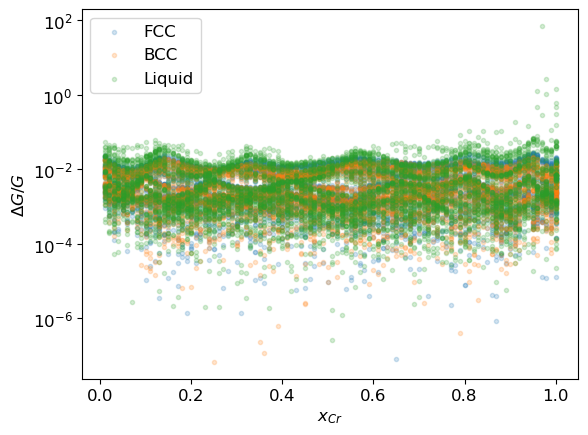

In [22]:
plt.close()
plt.scatter(X_test[:,0], np.abs((y_pred[:,0]-Y_test[:,0])/Y_test[:,0]), marker='.', alpha=0.2, label='FCC')
plt.scatter(X_test[:,0], np.abs((y_pred[:,1]-Y_test[:,1])/Y_test[:,1]), marker='.', alpha=0.2, label='BCC')
plt.scatter(X_test[:,0], np.abs((y_pred[:,2]-Y_test[:,2])/Y_test[:,2]), marker='.', alpha=0.2, label='Liquid')
plt.yscale('log')
plt.ylabel(r'$\Delta G / G$')
plt.xlabel(r'$x_{Cr}$')
plt.legend()
plt.show()

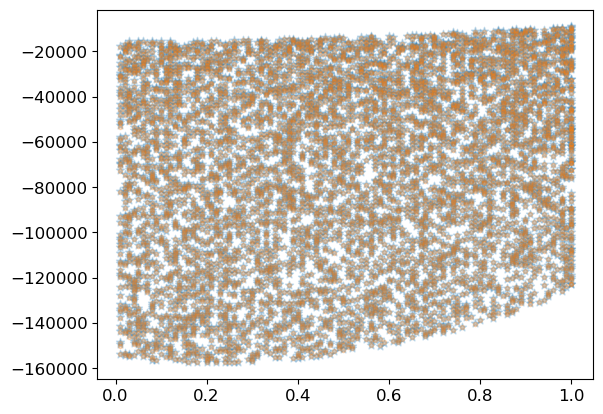

In [23]:
plt.close()

plt.scatter(X_test[:,0], Y_test[:,0], marker='*', alpha=0.25)
plt.scatter(X_test[:,0], y_pred[:,0], marker='.', alpha=0.25)
# plt.yscale('symlog')
plt.show()

/var/folders/wc/8ppk7xj10vbc_xtfrp0k7bnnjj2tt8/T/ipykernel_31507/3100547301.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.scatter(np.abs(Y_test[:,0]),np.abs(y_pred[:,0]),marker='.')


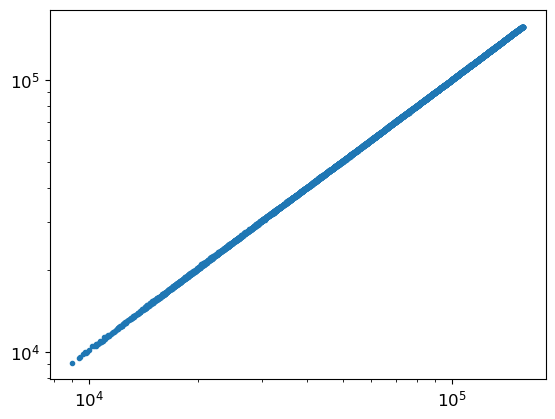

In [24]:
plt.scatter(np.abs(Y_test[:,0]),np.abs(y_pred[:,0]),marker='.')
# plt.plot(np.abs(np.linspace(np.min(Y_test[:,0]), np.max(Y_test[:,0]), 100)), np.abs(np.linspace(np.min(Y_test[:,0]), np.max(Y_test[:,0]), 100)))
plt.xscale('log')
plt.yscale('log')

In [25]:
with torch.no_grad():
    y_pred1 = model.to(device)(X_train.to(device)).cpu() * Y_std + Y_mean
    y_pred2 = model.to(device)(X_test.to(device)).cpu() * Y_std + Y_mean
    y_pred_all = model.to(device)(X_all.to(device)).cpu() * Y_std + Y_mean

# NN error
y_err1 = ((Y_train) - (y_pred1)) / (Y_train)
y_err2 = ((Y_test) - (y_pred2)) / (Y_test)
y_err_all = ((Y_all) - (y_pred_all)) / (Y_all)

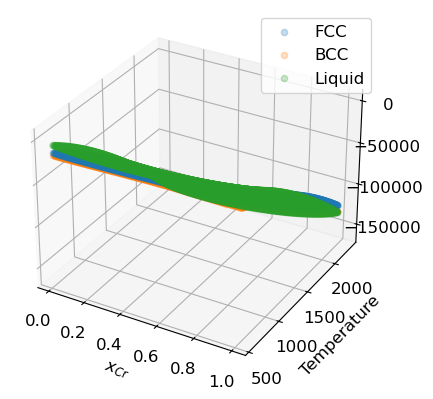

In [26]:
plt.close()
# plt.style.use('_mpl-gallery-nogrid')

fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax.scatter(X_all[:,0], X_all[:,1], Y_all[:,0], label=r'FCC', alpha=0.25)
ax.scatter(X_all[:,0], X_all[:,1], Y_all[:,1], label=r'BCC', alpha=0.25)
ax.scatter(X_all[:,0], X_all[:,1], Y_all[:,2], label=r'Liquid', alpha=0.25)
plt.xlabel(r'$x_{Cr}$')
plt.ylabel(r'Temperature')
plt.legend()
# plt.zlabel(r'$G$')
plt.show()


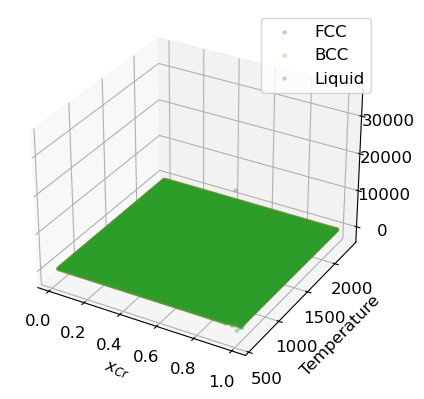

In [27]:
plt.close()
# plt.style.use('_mpl-gallery-nogrid')

fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax.scatter(X_all[:,0], X_all[:,1], y_err_all[:,0], label=r'FCC', marker='.', alpha=0.25)
ax.scatter(X_all[:,0], X_all[:,1], y_err_all[:,1], label=r'BCC', marker='.', alpha=0.25)
ax.scatter(X_all[:,0], X_all[:,1], y_err_all[:,2], label=r'Liquid', marker='.', alpha=0.25)
plt.xlabel(r'$x_{Cr}$')
plt.ylabel(r'Temperature')
plt.legend()
# plt.zlabel(r'$G$')
plt.show()

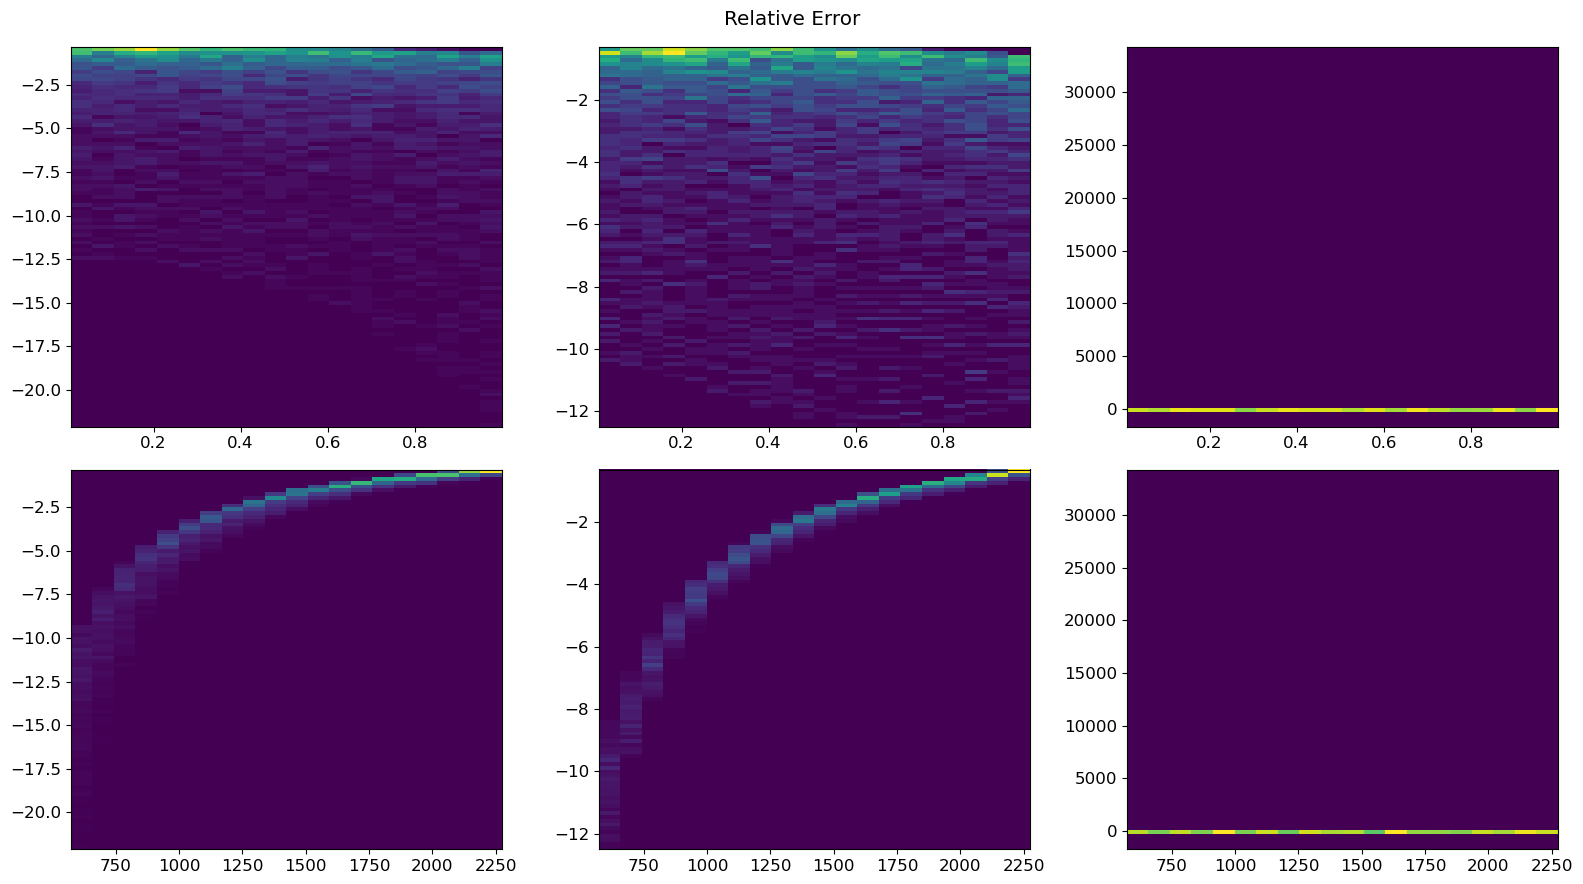

In [28]:
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(16,9))
for j in range(3):
  for i in range(2):
    ax[i][j].hist2d(X_test[:,i], y_err2[:,j], bins=[20,100])

fig.suptitle("Relative Error")

# show plot
fig.tight_layout()
# plt.savefig('figures/' + filename_prefix + 'error_heat_map.png')
plt.show()

In [29]:
torch.save(model, 'model.dat')

In [30]:
model_scripted = torch.jit.script(model)
model_scripted.save('model_scripted.pt')